In [1]:
from model import run_inference_pipeline
df = run_inference_pipeline()


  Total:   1,043,941
  Buyers:  1,377
  Rate:    0.1319%  ← class imbalance

Train observations: 1,577,139 (buyers: 1,465 | non-buyers: 1,575,674)
SPW: 32.80x
Val: 337,206 | Internal test: 373,699 | Kaggle test: 290,013
Clf features: 30 | Reg features: 30

STAGE 1 — CLASSIFICATION
Buyers: 251 / 337,206 | true rate: 0.000744
Baseline PR-AUC: 0.000744

  seed=0 | PR-AUC=0.0778 | iter=130
  seed=1 | PR-AUC=0.0809 | iter=130
  seed=2 | PR-AUC=0.0772 | iter=86
  seed=3 | PR-AUC=0.0785 | iter=77
  seed=4 | PR-AUC=0.0759 | iter=85

Mean PR-AUC (individual): 0.0781 ± 0.0016
True Ensemble PR-AUC:     0.0894
Baseline PR-AUC:          0.000744
Mean p_buy: 0.000752 | Calibration: 1.01x ✅

STAGE 2 — REGRESSION
Train buyers: 1,465 | Val buyers: 251 | Full buyers: 1,716
p99_log: 21.5837 | Baseline RMSE: 18.0156

  seed=0 | RMSE=1.2025 | iter=93
  seed=1 | RMSE=1.1967 | iter=161
  seed=2 | RMSE=1.1941 | iter=295
  seed=3 | RMSE=1.2053 | iter=110
  seed=4 | RMSE=1.2102 | iter=84

Mean RMSE (individual)

Tổng số khách hàng trong tập Test: 290,013

Thống kê mô tả các chỉ số quan trọng:


,p_buy,e_revenue,final_score
count,290013.000000,290013.000000,290013.000000
mean,0.000752,17.420083,0.013360
std,0.004481,0.282065,0.080211
min,0.000000,16.225164,0.000000
25%,0.000000,17.263600,0.000000
50%,0.000000,17.430647,0.000000
75%,0.000120,17.596158,0.002074
max,0.228796,19.916255,4.059895


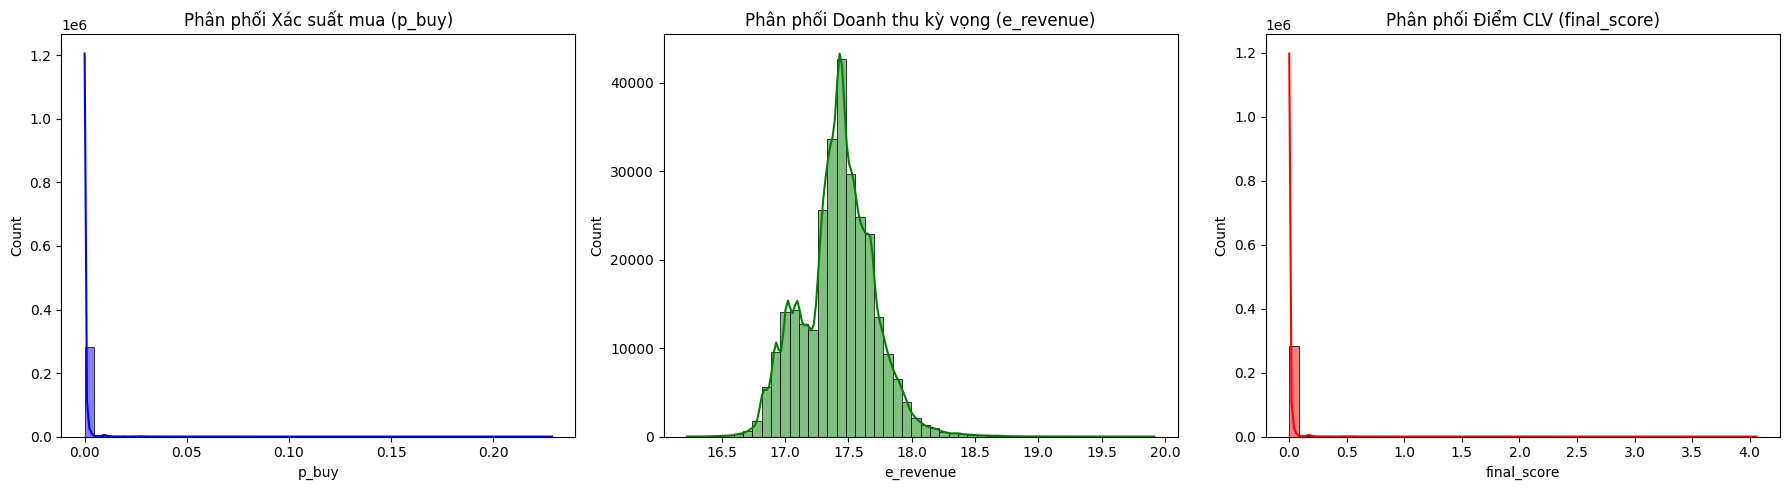


--- TOP 10 KHÁCH HÀNG GIÁ TRỊ NHẤT ---


,fullVisitorId,p_buy,e_revenue,final_score
142468,4911716496816548756,0.228796,17.744574,4.059895
268182,9249130983722228273,0.170324,19.113993,3.255575
98104,337985019851056231,0.177258,18.149125,3.217085
118948,4099631678878053818,0.170324,18.699203,3.184926
70836,2445892139164800406,0.170324,18.625671,3.172402
68017,2343446083763554039,0.171280,18.315960,3.137151
268786,9270456815186872247,0.173721,18.018502,3.130186
237335,8190324088698647362,0.175945,17.790483,3.130142
285123,9836145735124928648,0.172530,17.966696,3.099795
282292,9736461690764549162,0.170324,18.083569,3.080069


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Load prediction results
df_preds = pd.read_pickle('../data/test_predictions.pkl')

# 2. Overview check
print(f"Total customers in test set: {len(df_preds):,}")
print("\nDescriptive stats for key metrics:")
# Use display in Notebook, or print when running as a script
display(df_preds[['p_buy', 'e_revenue', 'final_score']].describe())

# 3. Check value distributions (important for detecting heavy skew)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_preds['p_buy'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Purchase probability distribution (p_buy)')

# e_revenue thường bị lệch phải, nên xem ở dạng log nếu cần
sns.histplot(df_preds['e_revenue'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Phân phối Doanh thu kỳ vọng (e_revenue)')

sns.histplot(df_preds['final_score'], bins=50, kde=True, ax=axes[2], color='red')
axes[2].set_title('CLV score distribution (final_score)')

plt.tight_layout()
plt.show()

# 4. Top 10 highest-value customers in test set
print("\n--- TOP 10 HIGHEST-VALUE CUSTOMERS ---")
display(df_preds.nlargest(10, 'final_score')[['fullVisitorId', 'p_buy', 'e_revenue', 'final_score']])


In [3]:
df_preds.info()

<class 'pandas.DataFrame'>
RangeIndex: 290013 entries, 0 to 290012
Data columns (total 70 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fullVisitorId                     290013 non-null  str    
 1   visitId_count                     290013 non-null  int64  
 2   visitNumber_max                   290013 non-null  int64  
 3   totals_hits_sum                   290013 non-null  int64  
 4   funnel_depth                      290013 non-null  float64
 5   totals_pageviews_sum              290013 non-null  float64
 6   totals_pageviews_mean             290013 non-null  float64
 7   totals_timeOnSite_sum             290013 non-null  float64
 8   totals_timeOnSite_mean            290013 non-null  float64
 9   totals_bounces_mean               290013 non-null  float64
 10  totals_sessionQualityDim_mean     290013 non-null  float64
 11  totals_sessionQualityDim_max      290013 non-null  int64  
 12 

In [4]:
df_preds.head()

,fullVisitorId,visitId_count,visitNumber_max,totals_hits_sum,funnel_depth,totals_pageviews_sum,totals_pageviews_mean,totals_timeOnSite_sum,totals_timeOnSite_mean,totals_bounces_mean,...,expected_purchases_92d,expected_monetary,interaction_hits_visits,interaction_time_visits,pageviews_per_session,ratio_revenue_hits,is_returning_visitor,p_buy,e_revenue,final_score
0,0000018966949534117,1,1,7,7.0,7.0,7.0,131.0,131.0,0.0,...,0.0,0.0,2.079442,4.882802,7.0,0.0,0,0.000409,17.312914,0.007088
1,0000039738481224681,1,1,1,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.693147,0.000000,1.0,0.0,0,0.000000,17.388577,0.000000
2,0000073585230191399,1,1,1,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.693147,0.000000,1.0,0.0,0,0.000000,16.817656,0.000000
3,0000087588448856385,1,1,1,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.693147,0.000000,1.0,0.0,0,0.000000,17.362838,0.000000
4,0000149787903119437,1,1,1,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.693147,0.000000,1.0,0.0,0,0.000000,17.022317,0.000000


In [8]:

train_df = pd.read_pickle('../data/train_final.pkl')

val_df = pd.read_pickle('../data/val_final.pkl')

In [9]:
# Quick debug check on train_df
print(train_df['fullVisitorId'].nunique())      # unique users
print(len(train_df))                            # total observations
print(train_df[train_df['target_revenue'] > 0]['fullVisitorId'].nunique())  # unique buyers

769507
1577139
1176


In [10]:
train_buyer_ids = set(train_df[train_df['target_revenue'] > 0]['fullVisitorId'])
val_buyer_ids   = set(val_df[val_df['target_revenue'] > 0]['fullVisitorId'])

overlap = train_buyer_ids & val_buyer_ids
print(f"Train buyers:    {len(train_buyer_ids)}")  # unique buyers in train
print(f"Val buyers:      {len(val_buyer_ids)}")    # unique buyers in val
print(f"Overlap:         {len(overlap)}")           # overlap in both sets

Train buyers:    1176
Val buyers:      251
Overlap:         50
